In [ ]:
from ast import increment_lineno
import io
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')
%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


sns.set(style="whitegrid")





In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Formula1_Pitstop_Data_1950-2024_all_rounds.csv to Formula1_Pitstop_Data_1950-2024_all_rounds.csv


In [ ]:
df = pd.read_csv(io.BytesIO(uploaded['Formula1_Pitstop_Data_1950-2024_all_rounds.csv']))

In [ ]:
df.head()

,Season,Round,Circuit,Driver,Constructor,Laps,Position,TotalPitStops,AvgPitStopTime,PitStops
0,1950,1,Silverstone Circuit,Nino Farina,Alfa Romeo,70,1,0,NaN,[]
1,1950,1,Silverstone Circuit,Luigi Fagioli,Alfa Romeo,70,2,0,NaN,[]
2,1950,1,Silverstone Circuit,Reg Parnell,Alfa Romeo,70,3,0,NaN,[]
3,1950,1,Silverstone Circuit,Yves Cabantous,Talbot-Lago,68,4,0,NaN,[]
4,1950,1,Silverstone Circuit,Louis Rosier,Talbot-Lago,68,5,0,NaN,[]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Season          26759 non-null  int64  
 1   Round           26759 non-null  int64  
 2   Circuit         26759 non-null  object 
 3   Driver          26759 non-null  object 
 4   Constructor     26759 non-null  object 
 5   Laps            26759 non-null  int64  
 6   Position        26759 non-null  int64  
 7   TotalPitStops   26759 non-null  int64  
 8   AvgPitStopTime  5575 non-null   float64
 9   PitStops        26759 non-null  object 
dtypes: float64(1), int64(5), object(4)
memory usage: 2.0+ MB


In [ ]:
##Data cleaning and preprocessing
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

Missing values in each column:
Season                0
Round                 0
Circuit               0
Driver                0
Constructor           0
Laps                  0
Position              0
TotalPitStops         0
AvgPitStopTime    21184
PitStops              0
dtype: int64


In [ ]:
df = df.dropna(subset=['AvgPitStopTime'])

In [ ]:
missing_values1 = df.isnull().sum()
print(missing_values1)

Season            0
Round             0
Circuit           0
Driver            0
Constructor       0
Laps              0
Position          0
TotalPitStops     0
AvgPitStopTime    0
PitStops          0
dtype: int64


In [ ]:
df['Season'] = df['Season'].astype(int)
df['Round'] = df['Round'].astype(int)
df['Laps'] = df['Laps'].astype(int)
df['Position'] = df['Position'].astype(int)
df['TotalPitStops'] = df['TotalPitStops'].astype(int)

In [ ]:
print("Data cleaning complete!!")

Data cleaning complete!!


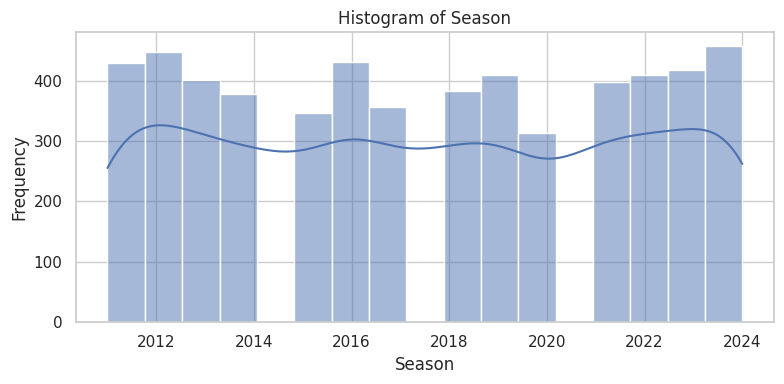

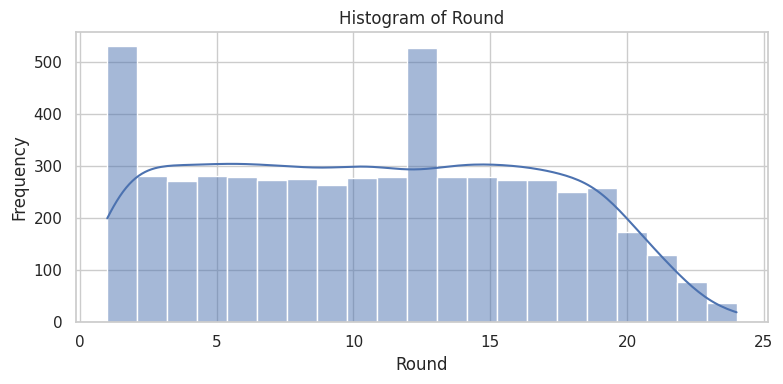

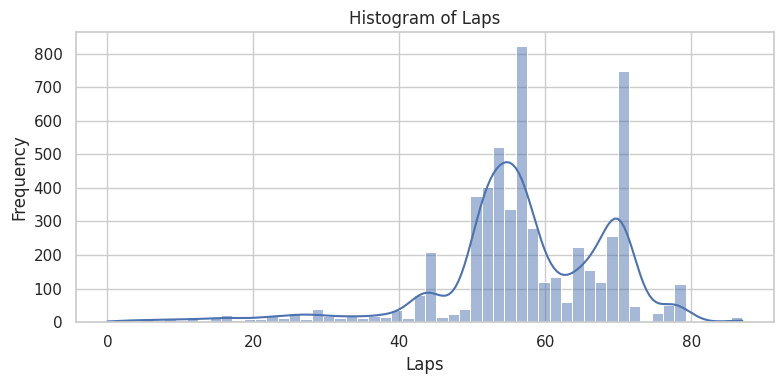

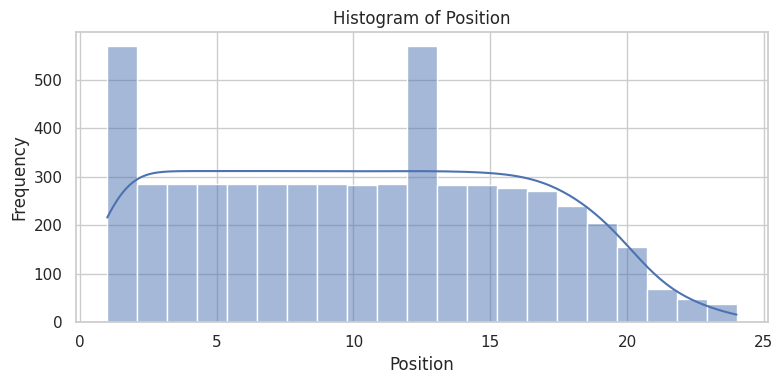

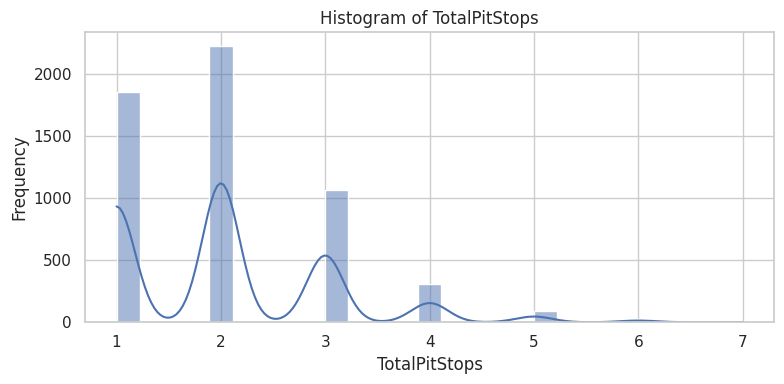

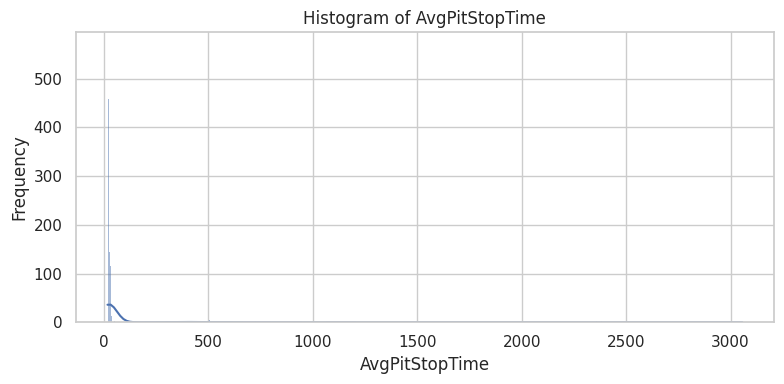

In [ ]:
numeric_cols = ['Season', 'Round', 'Laps', 'Position', 'TotalPitStops', 'AvgPitStopTime']
for col in numeric_cols:
  plt.figure(figsize=(8, 4))
  sns.histplot(df[col], kde=True)
  plt.title(f'Histogram of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()

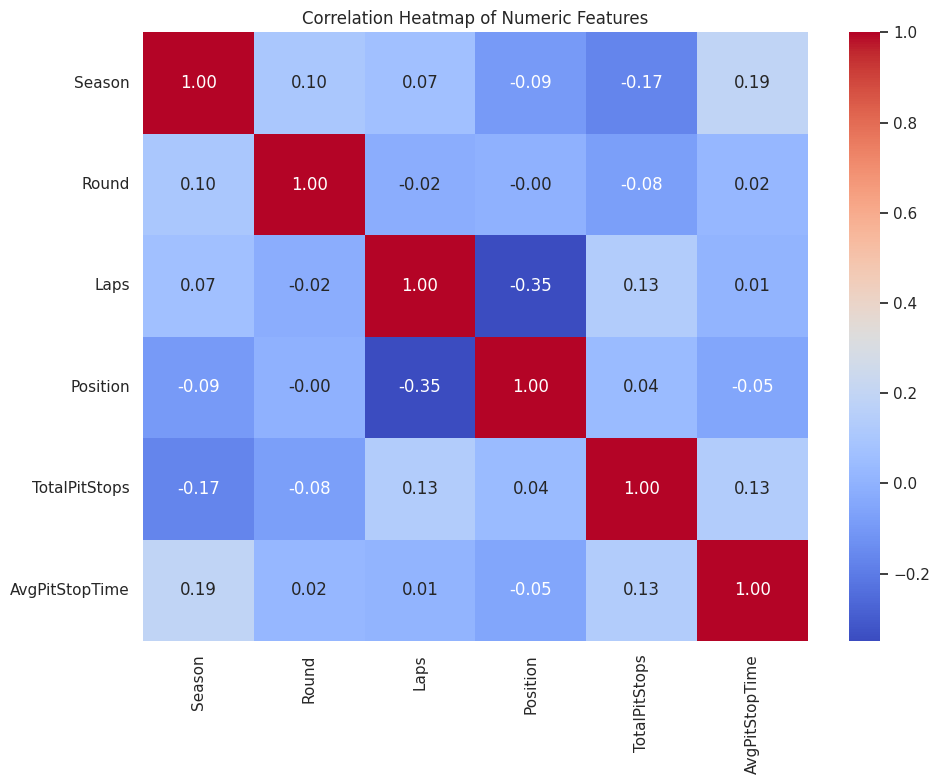

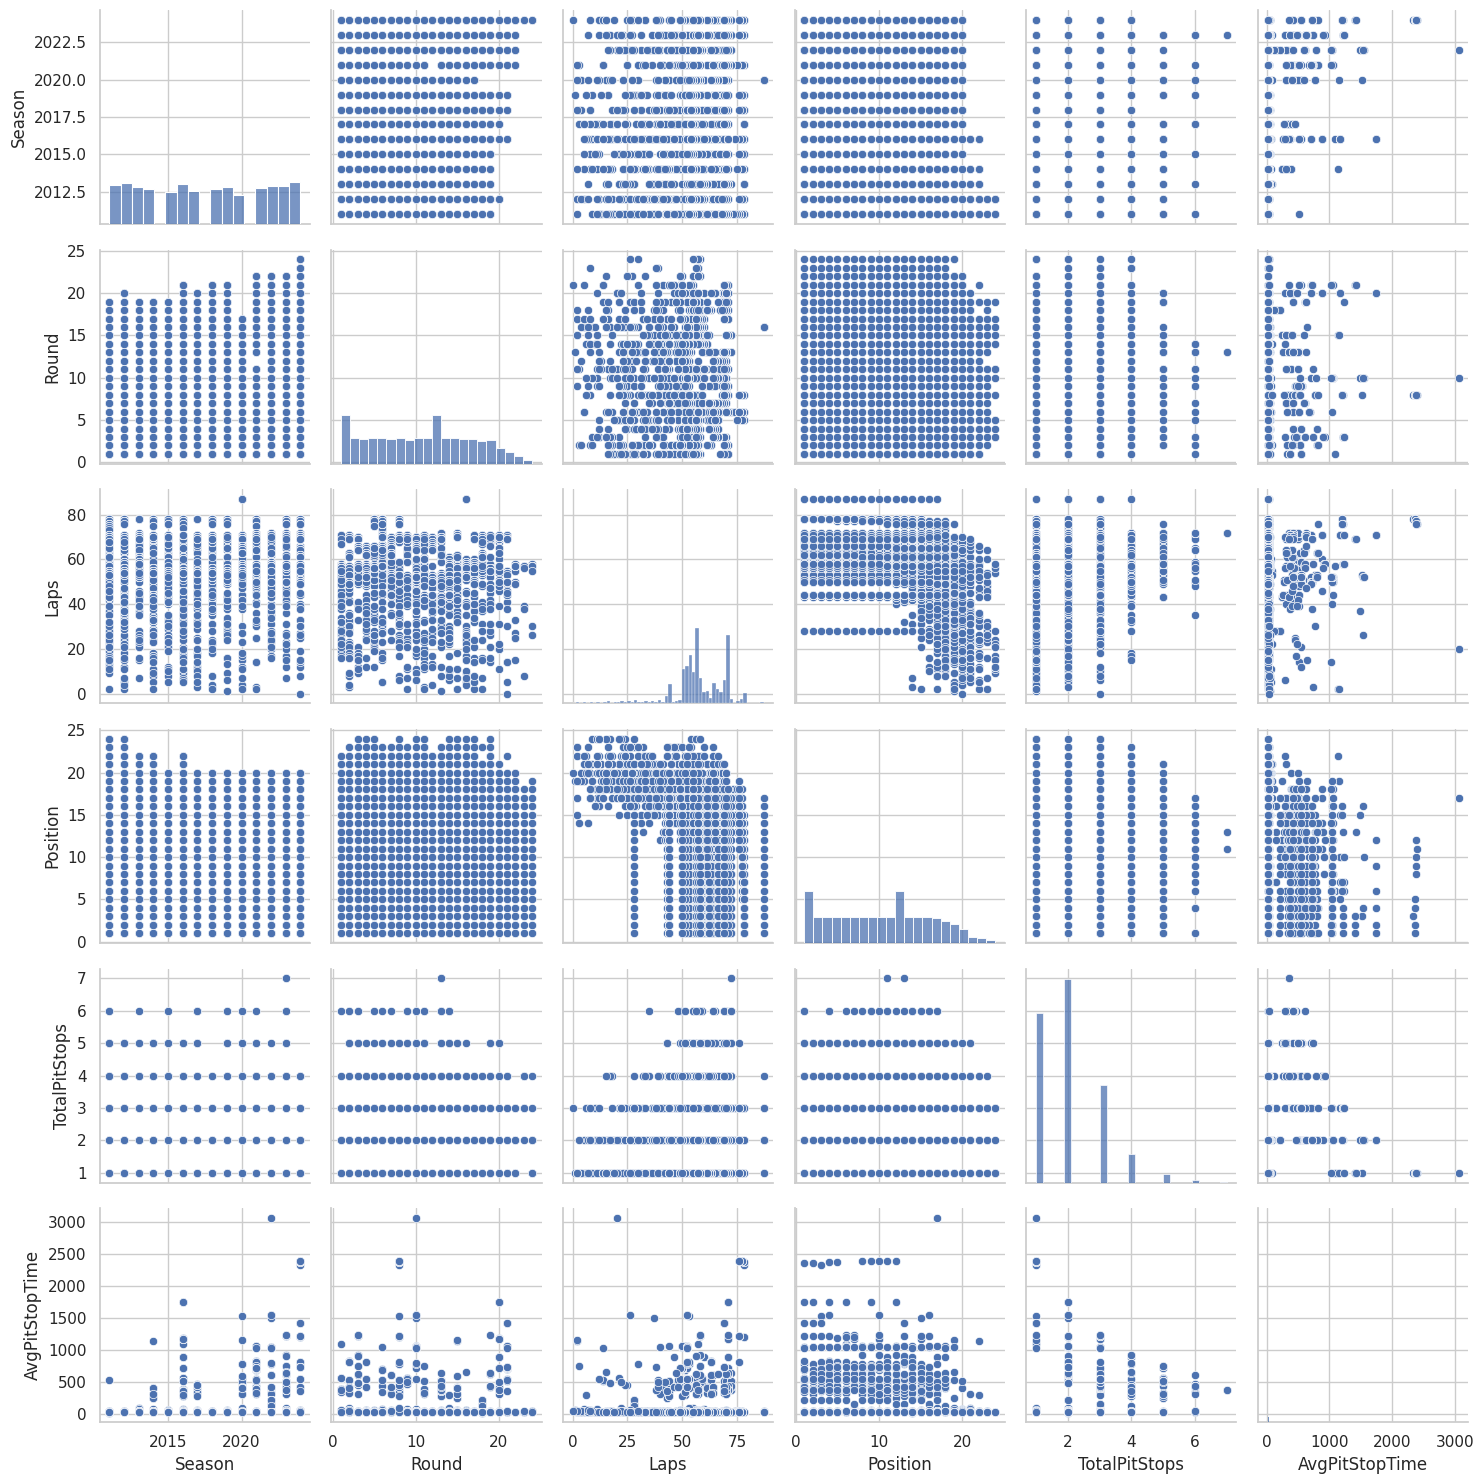

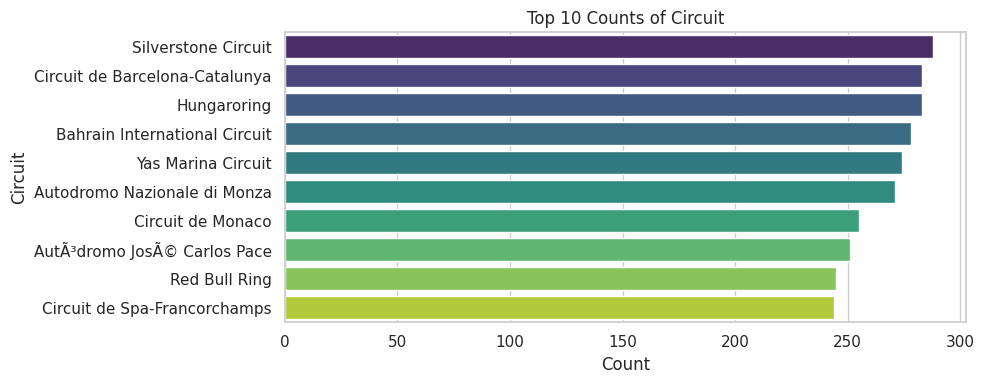

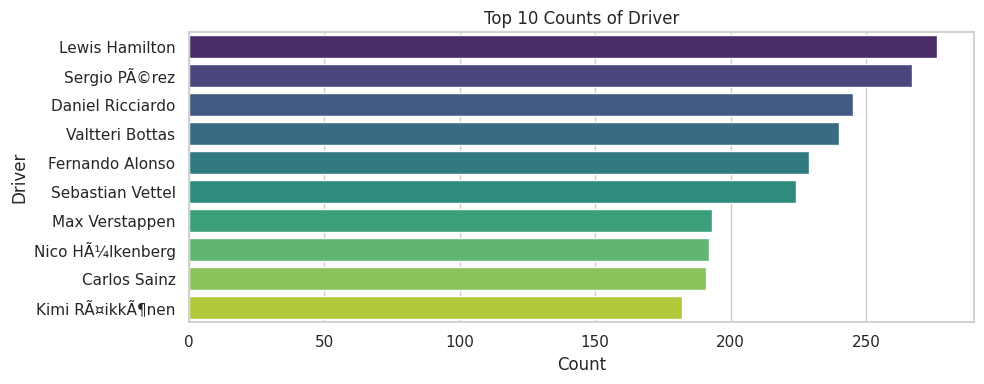

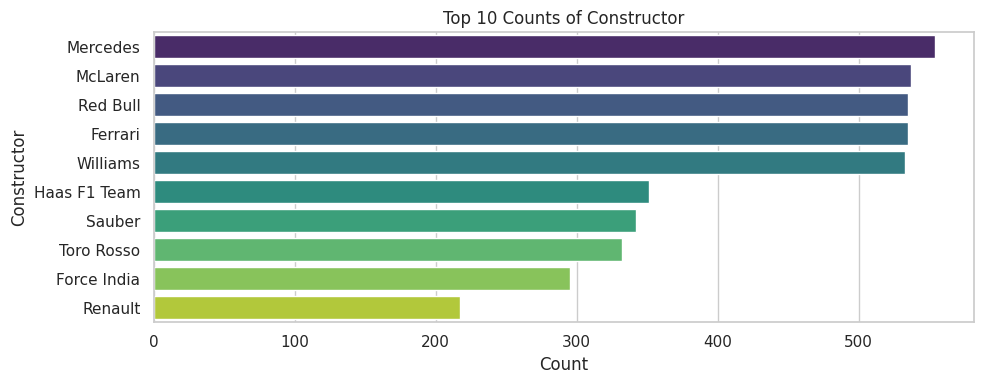

In [ ]:
numeric_df = df[numeric_cols]
if numeric_df.shape[1] >= 4:
  plt.figure(figsize=(10,8))
  corr = numeric_df.corr()
  sns.heatmap(corr, annot=True, cmap='coolwarm', fmt= '.2f')
  plt.title('Correlation Heatmap of Numeric Features')
  plt.tight_layout()
  plt.show()

sns.pairplot(numeric_df)
plt.tight_layout()
plt.show()

categorical_cols = ['Circuit', 'Driver', 'Constructor']
for col in categorical_cols:
  plt.figure(figsize=(10, 4))
  order = df[col].value_counts().iloc[:10].index
  sns.countplot(data=df, y=col, order=order, palette = 'viridis')
  plt.title(f'Top 10 Counts of {col}')
  plt.xlabel('Count')
  plt.ylabel(col)
  plt.tight_layout()
  plt.show()

Mean Squared Error: 7011.705817419626
R2 score: 0.8650505122416494


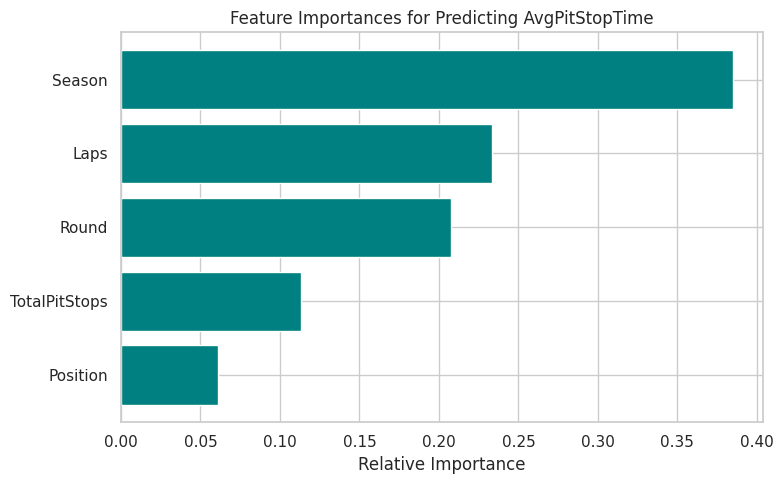

In [ ]:
target = 'AvgPitStopTime'
features = ['Season', 'Round', 'Laps', 'Position', 'TotalPitStops']
X = df[features]
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R2 score: {r2}")


importances = model.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importances for Predicting AvgPitStopTime')
plt.tight_layout()
plt.show()